In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
new_dir = "/content/drive/My Drive/CSCI566-S25-Material"
os.chdir(new_dir)
current_dir = os.getcwd()
print(f"new directory: {current_dir}")

Mounted at /content/drive
new directory: /content/drive/My Drive/CSCI566-S25-Material


In [ ]:
!pip install scapy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 36.9 MB/s eta 0:00:00


###Why AutoEncoder for Intelligent Caching?
learn the model of DNS:
  * high similarity: it's the popular search
  * low similarity: it might be uncommon search/bad search

In [ ]:
import numpy as np
from scapy.utils import RawPcapReader
from scapy.layers.inet import IP, TCP, UDP

pcap_file = "data.mia.pcap"
features = []

for i, (pkt_data, pkt_metadata) in enumerate(RawPcapReader(pcap_file)):
    try:
        packet = IP(pkt_data)
    except:
        continue
    if packet:
        feature = [
          len(packet),  # packet size
          getattr(packet, 'time', 0),  # time
          int(ipaddress.IPv4Address(packet.src)) if hasattr(packet, 'src') else 0,  # source ip
          int(ipaddress.IPv4Address(packet.dst)) if hasattr(packet, 'dst') else 0,  # target ip
          getattr(packet, 'proto', 0),  # protocol type
          getattr(packet, 'sport', -1),  # source port
          getattr(packet, 'dport', -1),  # target port
          getattr(packet, 'ttl', 64),  # TTL
          getattr(packet, 'len', 0),  # IP packet size
          getattr(packet, 'id', 0),  # id
          getattr(packet, 'frag_offset', 0),  
        ]
        features.append(feature)

    if i >= 3200:
        break

features = np.array(features)



print(features[:10],type(features[0][0]))

[[ 1.07600000e+03  1.74185533e+09  1.34235392e+08  6.96049430e+07
   5.00000000e+00 -1.00000000e+00 -1.00000000e+00  1.94000000e+02
   4.60080000e+04  3.66900000e+03  0.00000000e+00]
 [ 6.60000000e+01  1.74185533e+09  1.34235392e+08  3.46469800e+06
   1.86000000e+02 -1.00000000e+00 -1.00000000e+00  1.79000000e+02
   4.96690000e+04  5.57580000e+04  0.00000000e+00]
 [ 6.60000000e+01  1.74185533e+09  1.34235392e+08  3.40787200e+06
   1.86000000e+02 -1.00000000e+00 -1.00000000e+00  1.79000000e+02
   4.96690000e+04  5.57580000e+04  0.00000000e+00]
 [ 8.60000000e+01  1.74185533e+09  2.26265498e+09  3.20000000e+01
   1.84000000e+02 -1.00000000e+00 -1.00000000e+00  1.79000000e+02
   4.96690000e+04  5.57580000e+04  0.00000000e+00]
 [ 6.60000000e+01  1.74185533e+09  1.34235392e+08  3.45808800e+06
   5.00000000e+00 -1.00000000e+00 -1.00000000e+00  1.94000000e+02
   4.60080000e+04  3.66900000e+03  0.00000000e+00]
 [ 6.60000000e+01  1.74185533e+09  1.34235396e+08  3.41503500e+06
   1.84000000e+02 -

In [ ]:

scaler = StandardScaler()
features = scaler.fit_transform(features)  # to [0,1]
print(features[:10],type(features[0][0]))



[[ 1.61016324 -1.72638714 -0.55413366 -0.12928575 -1.08374981  0.
   0.          1.08378614 -1.08378614 -1.08378614  0.        ]
 [-0.70180805 -1.72411521 -0.55413366 -0.24247639  0.93426744  0.
   0.         -0.92269126  0.92269126  0.92269126  0.        ]
 [-0.70180805 -1.72326267 -0.55413366 -0.24257364  0.93426744  0.
   0.         -0.92269126  0.92269126  0.92269126  0.        ]
 [-0.65602644 -1.7223898   1.80461876 -0.24840572  0.91196891  0.
   0.         -0.92269126  0.92269126  0.92269126  0.        ]
 [-0.70180805 -1.72093916 -0.55413366 -0.2424877  -1.08374981  0.
   0.          1.08378614 -1.08378614 -1.08378614  0.        ]
 [-0.70180805 -1.7196368  -0.55413365 -0.24256138  0.91196891  0.
   0.         -0.92269126  0.92269126  0.92269126  0.        ]
 [ 1.80015692 -1.71862358 -0.55413366 -0.11997574 -1.08374981  0.
   0.          1.08378614 -1.08378614 -1.08378614  0.        ]
 [-0.65831552 -1.71748934 -0.55413366 -0.24041866  0.93426744  0.
   0.         -0.92269126  0.92

vanilla antoencoders

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 4)
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

input_dim = features.shape[1]
model = Autoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

features_tensor = torch.tensor(features, dtype=torch.float32)

train_data = features_tensor[:2000]
validation_data = features_tensor[2000:2600]
test_data = features_tensor[2600:3200]
print(f"Training Data Size: {len(train_data)}")
print(f"Validation Data Size: {len(validation_data)}")
print(f"Test Data Size: {len(test_data)}")

num_epochs = 200
batch_size = 128

train_dataset = TensorDataset(train_data)
validation_dataset = TensorDataset(validation_data)
test_dataset = TensorDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


Training Data Size: 2000
Validation Data Size: 600
Test Data Size: 600


In [ ]:
train_loss=[]
val_loss=[]
for epoch in range(num_epochs):
    # train
    model.train()
    cache_hits = 0
    cache_misses = 0
    for batch in train_loader:
        batch_data = batch[0]  # DataLoader will return (data, label) tuple, here is only the data
        optimizer.zero_grad()
        outputs = model(batch_data)
         # we should know what data should be cached as premise
        predicted_data = outputs  # this is the predicted data to cache
        print(predicted_data[0])
        
        actual_data = batch[1]  # hope there is cache label
        print(actual_data[0])
        for j in range(len(batch)):
            if predicted_data[j] == actual_data[j]:  # if the prediction is equal to real data, then it is a hit
                cache_hits += 1
            else:
                cache_misses += 1
        loss = criterion(outputs, batch_data)
        loss.backward()
        optimizer.step()

    cache_hit_rate = cache_hits / len(train_data)
    cache_miss_rate = cache_misses / len(train_data)
    train_loss.append(loss.item())
    print(f"Cache Hit Rate: {cache_hit_rate:.4f}, Cache Miss Rate: {cache_miss_rate:.4f}")

    # validate
    model.eval()
    with torch.no_grad():
        val_epoch_loss = 0
        for batch in validation_loader:
            batch_data = batch[0]
            outputs = model(batch_data)
            loss = criterion(outputs, batch_data)
            val_epoch_loss += loss.item()

        val_loss.append(val_epoch_loss / len(validation_loader))

    # print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}, Validation Loss: {val_loss[-1]:.4f}")

# test
model.eval()
test_loss = 0
with torch.no_grad():
    for batch in test_loader:
        batch_data = batch[0]
        outputs = model(batch_data)
        loss = criterion(outputs, batch_data)
        test_loss += loss.item()

print(f"Test Loss: {test_loss / len(test_loader):.4f}")

tensor([ 1.9796, -1.5387, -0.5297, -0.1293, -1.0951,  0.0083, -0.0118,  1.0780,
        -1.0881, -1.0913,  0.0096], grad_fn=<SelectBackward0>)


IndexError: list index out of range

graph of loss

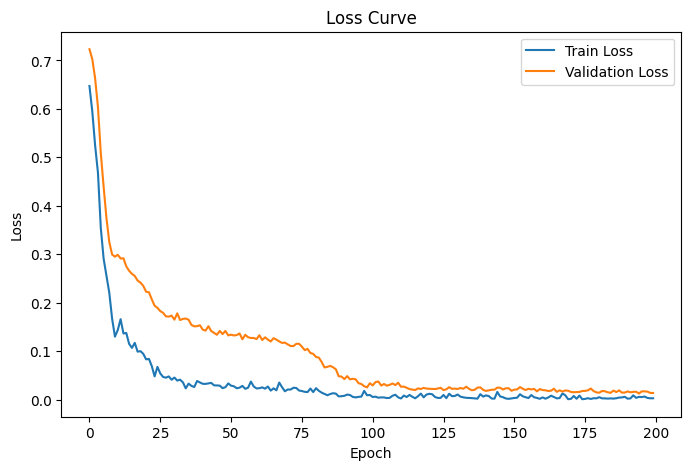

In [ ]:
import matplotlib.pyplot as plt

def plot_loss(train_losses, val_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss Curve")
    plt.show()

plot_loss(train_loss,val_loss)

In [ ]:
reconstructed = model(features_tensor).detach().numpy()
errors = np.mean((features - reconstructed) ** 2, axis=1)

# set threshold to decide if it is needed to cache
threshold = np.percentile(errors, 95)
to_cache = features[errors > threshold]

print(f"percentage of cache-needed: {len(to_cache)}/{len(features)}")


需要缓存的流量占比: 100/2001
